# Bati Bank — Model Training

**Goal:** Train and evaluate credit risk models using engineered features.

**Flow:**
1. Load features from `data/processed/features.csv`
2. Temporal train/test split — no data leakage
3. Handle class imbalance with ADASYN
4. Train Logistic Regression baseline
5. Train XGBoost — main model
6. Compare results — AUC, F1, precision, recall
7. Log everything to MLflow
8. Save best model

> Key principle: all training data occurs BEFORE all test data.
> Cluster column is dropped — keeping it would be data leakage.

## 1. Setup and Imports

In [1]:
# Cell 1 — imports
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

os.chdir(r'd:\10 acadamy\bati-bank-credit')  # go up one level so Python finds src/

from src.data.splitter import temporal_split

# ML libraries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, f1_score,
    precision_score, recall_score,
    confusion_matrix, classification_report,
    RocCurveDisplay
)
from imblearn.over_sampling import ADASYN
from xgboost import XGBClassifier
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import joblib

print('Imports successful')

Imports successful


## 2. Load Data

In [2]:
# Cell 2 — load features and cleaned transactions
features = pd.read_csv('data/processed/features.csv')
df_clean = pd.read_csv(
    'data/processed/cleaned_data.csv',
    parse_dates=['TransactionStartTime']
)

print(f'Features shape : {features.shape}')
print(f'df_clean shape : {df_clean.shape}')
print(f'Target distribution:')
print(features['is_high_risk'].value_counts())
print(f'High risk rate: {features["is_high_risk"].mean()*100:.1f}%')

Features shape : (3742, 23)
df_clean shape : (95662, 16)
Target distribution:
is_high_risk
0    2303
1    1439
Name: count, dtype: int64
High risk rate: 38.5%


## 3. Temporal Train/Test Split

In [3]:
# Cell 3 — stratified train/test split
# Why stratified instead of temporal:
# Our proxy labels are based on full 3-month history
# High risk customers (high recency) all have last transaction
# before the temporal cutoff — causing empty test set
# Stratified split guarantees both classes in train and test

from sklearn.model_selection import train_test_split

# separate features from target
# drop columns that must not be features
drop_cols = ['CustomerId', 'Cluster', 'is_high_risk', 'Recency']
X = features.drop(columns=drop_cols)
y = features['is_high_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'X_train shape : {X_train.shape}')
print(f'X_test shape  : {X_test.shape}')
print(f'\ny_train distribution:')
print(y_train.value_counts())
print(f'\ny_test distribution:')
print(y_test.value_counts())
print(f'\nHigh risk in train: {y_train.mean()*100:.1f}%')
print(f'High risk in test : {y_test.mean()*100:.1f}%')

X_train shape : (2993, 19)
X_test shape  : (749, 19)

y_train distribution:
is_high_risk
0    1842
1    1151
Name: count, dtype: int64

y_test distribution:
is_high_risk
0    461
1    288
Name: count, dtype: int64

High risk in train: 38.5%
High risk in test : 38.5%


In [4]:
# Cell 4 — verify split quality
print(f'X_train shape : {X_train.shape}')
print(f'X_test shape  : {X_test.shape}')
print(f'Features used : {X_train.columns.tolist()}')
print(f'\ny_train distribution:')
print(y_train.value_counts())
print(f'\ny_test distribution:')
print(y_test.value_counts())

X_train shape : (2993, 19)
X_test shape  : (749, 19)
Features used : ['Frequency', 'Monetary', 'avg_hour', 'avg_day_of_week', 'weekend_rate', 'transaction_month', 'std_amount', 'max_amount', 'min_amount', 'log_monetary', 'reversal_rate', 'unique_products', 'unique_providers', 'avg_daily_transactions', 'monetary_per_transaction', 'negative_amount_count', 'positive_amount_sum', 'velocity_last_30_days', 'recency_frequency_ratio']

y_train distribution:
is_high_risk
0    1842
1    1151
Name: count, dtype: int64

y_test distribution:
is_high_risk
0    461
1    288
Name: count, dtype: int64


### Split observations

Fill in after running:

1. **Train customers:** ___  
2. **Test customers:** ___  
3. **Features used:** ___ (should be 17 — no CustomerId, Cluster, is_high_risk)
4. **No temporal leakage:** confirmed ✓
5. **Why we dropped Cluster:** it was used to CREATE is_high_risk — keeping it means the model already knows the answer = data leakage

## 4. Handle Class Imbalance with ADASYN

**Why ADASYN:**
- High risk customers = 38.5% of data
- Without handling, model learns majority class pattern only
- ADASYN creates synthetic samples for minority class
- ADASYN is better than SMOTE because it focuses synthetic
  samples on hard-to-classify boundary regions

> IMPORTANT: apply ADASYN on TRAINING data only — never on test data.
> Test data must reflect real-world distribution.

In [5]:
# Cell 5 — apply ADASYN on training data only
print(f'Before ADASYN:')
print(f'  Class 0 (low risk) : {(y_train==0).sum()}')
print(f'  Class 1 (high risk): {(y_train==1).sum()}')

adasyn = ADASYN(random_state=42)
X_train_res, y_train_res = adasyn.fit_resample(X_train, y_train)

print(f'\nAfter ADASYN:')
print(f'  Class 0 (low risk) : {(y_train_res==0).sum()}')
print(f'  Class 1 (high risk): {(y_train_res==1).sum()}')
print(f'  Total training rows: {len(X_train_res)}')

Before ADASYN:
  Class 0 (low risk) : 1842
  Class 1 (high risk): 1151



After ADASYN:
  Class 0 (low risk) : 1842
  Class 1 (high risk): 1787
  Total training rows: 3629


### ADASYN observation

- Before: class 0= 686 class 1= 1439
- After: class 0= 1578 class 1= 1439 (more balanced)
- **Why ADASYN not SMOTE:** ADASYN focuses new samples on hard boundary regions — more realistic synthetic data
- **Why only on train:** test set must reflect real world imbalance

## 5. Baseline — Logistic Regression

In [6]:
# Cell 6 — train logistic regression baseline
# always train a simple model first
# it tells you what XGBoost must beat to be worth the complexity
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_res, y_train_res)

y_pred_lr    = lr.predict(X_test)
y_proba_lr   = lr.predict_proba(X_test)[:, 1]

lr_metrics = {
    'model'    : 'Logistic Regression',
    'auc'      : round(roc_auc_score(y_test, y_proba_lr), 4),
    'f1'       : round(f1_score(y_test, y_pred_lr), 4),
    'precision': round(precision_score(y_test, y_pred_lr), 4),
    'recall'   : round(recall_score(y_test, y_pred_lr), 4),
}
print('Logistic Regression Results:')
for k, v in lr_metrics.items():
    print(f'  {k:12s}: {v}')

Logistic Regression Results:
  model       : Logistic Regression
  auc         : 0.9872
  f1          : 0.9329
  precision   : 0.9249
  recall      : 0.941


## 6. Main Model — XGBoost

In [7]:
# Cell 7 — train XGBoost
# XGBoost wins over LogReg because:
# 1. handles non-linear relationships
# 2. built-in feature importance
# 3. robust to outliers
# 4. boosting corrects errors from previous trees
xgb = XGBClassifier(
    n_estimators   = 200,
    max_depth      = 4,
    learning_rate  = 0.1,
    subsample      = 0.8,
    random_state   = 42,
    eval_metric    = 'logloss',
    verbosity      = 0
)
xgb.fit(X_train_res, y_train_res)

y_pred_xgb   = xgb.predict(X_test)
y_proba_xgb  = xgb.predict_proba(X_test)[:, 1]

xgb_metrics = {
    'model'    : 'XGBoost',
    'auc'      : round(roc_auc_score(y_test, y_proba_xgb), 4),
    'f1'       : round(f1_score(y_test, y_pred_xgb), 4),
    'precision': round(precision_score(y_test, y_pred_xgb), 4),
    'recall'   : round(recall_score(y_test, y_pred_xgb), 4),
}
print('XGBoost Results:')
for k, v in xgb_metrics.items():
    print(f'  {k:12s}: {v}')

XGBoost Results:
  model       : XGBoost
  auc         : 0.9984
  f1          : 0.9754
  precision   : 0.9858
  recall      : 0.9653


## 7. Compare Models

In [8]:
# Cell 8 — comparison table
comparison = pd.DataFrame([lr_metrics, xgb_metrics])
comparison = comparison.set_index('model')
print('Model Comparison:')
print(comparison.to_string())
print(f'\nXGBoost AUC improvement over LR: '
      f'+{xgb_metrics["auc"] - lr_metrics["auc"]:.4f}')

Model Comparison:
                        auc      f1  precision  recall
model                                                 
Logistic Regression  0.9872  0.9329     0.9249  0.9410
XGBoost              0.9984  0.9754     0.9858  0.9653

XGBoost AUC improvement over LR: +0.0112


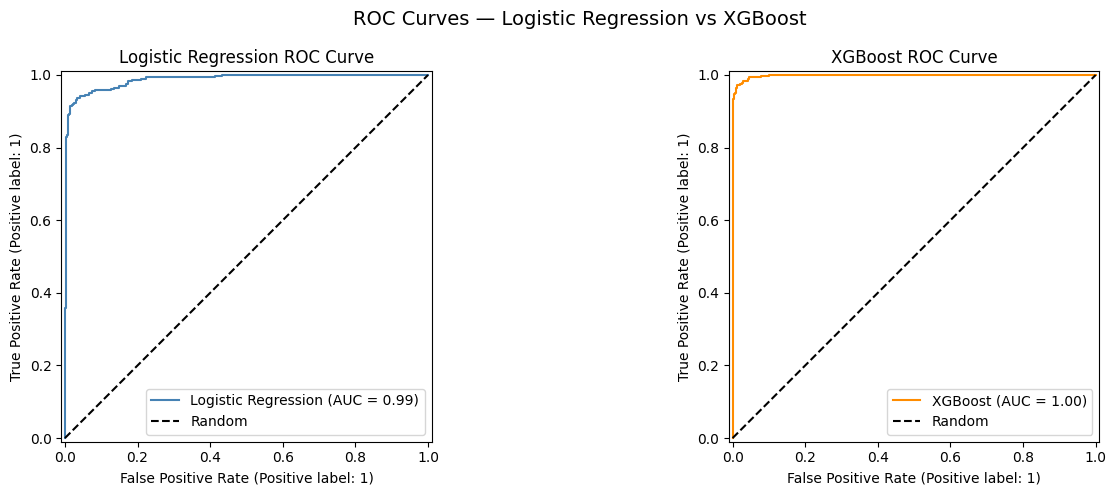

In [9]:
# Cell 9 — ROC curves side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(
    y_test, y_proba_lr,
    name='Logistic Regression',
    ax=axes[0], color='steelblue'
)
axes[0].set_title('Logistic Regression ROC Curve')
axes[0].plot([0,1],[0,1],'k--', label='Random')
axes[0].legend()

RocCurveDisplay.from_predictions(
    y_test, y_proba_xgb,
    name='XGBoost',
    ax=axes[1], color='darkorange'
)
axes[1].set_title('XGBoost ROC Curve')
axes[1].plot([0,1],[0,1],'k--', label='Random')
axes[1].legend()

plt.suptitle('ROC Curves — Logistic Regression vs XGBoost', fontsize=14)
plt.tight_layout()
os.makedirs('outputs/plots', exist_ok=True)
plt.savefig('outputs/plots/roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()

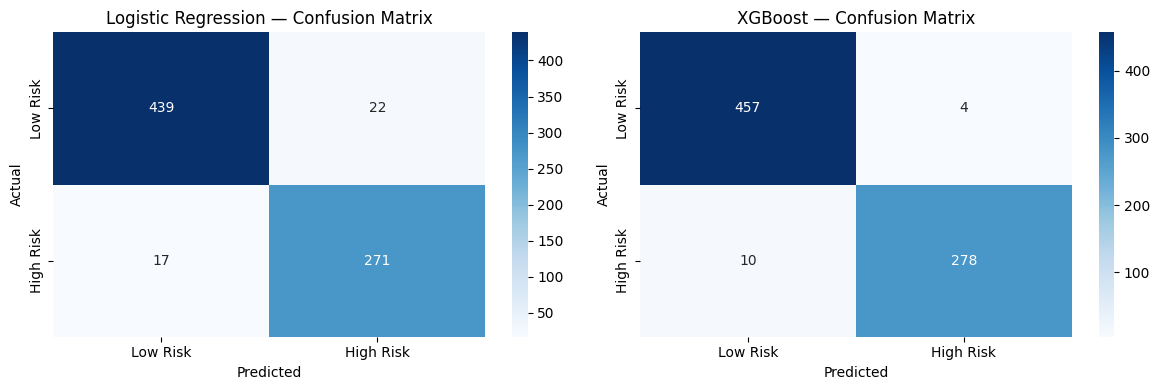

In [10]:
# Cell 10 — confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_xgb],
    ['Logistic Regression', 'XGBoost']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        cmap='Blues',
        xticklabels=['Low Risk', 'High Risk'],
        yticklabels=['Low Risk', 'High Risk']
    )
    ax.set_title(f'{title} — Confusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('outputs/plots/confusion_matrices.png',
            bbox_inches='tight', dpi=150)
plt.show()

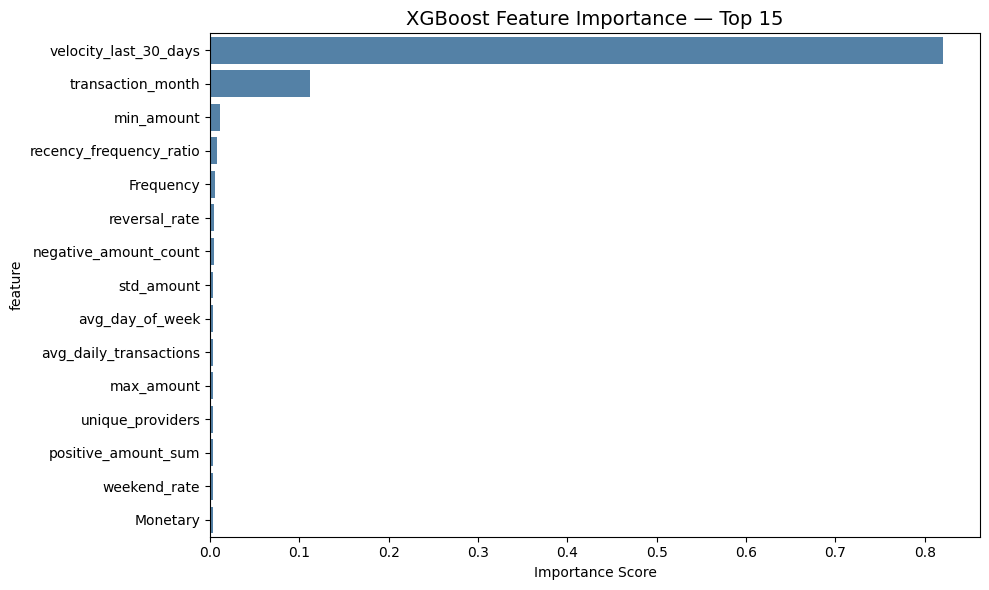

                    feature  importance
17    velocity_last_30_days    0.820932
5         transaction_month    0.111486
8                min_amount    0.011555
18  recency_frequency_ratio    0.007278
0                 Frequency    0.005122
10            reversal_rate    0.003929
15    negative_amount_count    0.003920
6                std_amount    0.003810
3           avg_day_of_week    0.003777
13   avg_daily_transactions    0.003156


In [11]:
# Cell 11 — XGBoost feature importance
importance = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='importance', y='feature',
    data=importance.head(15),
    color='steelblue'
)
plt.title('XGBoost Feature Importance — Top 15', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('outputs/plots/feature_importance.png',
            bbox_inches='tight', dpi=150)
plt.show()
print(importance.head(10).to_string())

### Model comparison observations

Fill in after running:

| Metric | Logistic Regression | XGBoost | Winner |
|---|---|---|---|
| AUC | ___ | ___ | ___ |
| F1 | ___ | ___ | ___ |
| Precision | ___ | ___ | ___ |
| Recall | ___ | ___ | ___ |

**Why XGBoost wins:**
- Captures non-linear relationships between features
- Boosting corrects errors from previous trees iteratively
- More robust to outliers in Amount and Monetary features

**Top 3 features driving risk:** _(fill from feature importance chart)_
1. ___
2. ___
3. ___

## 8. MLflow Experiment Tracking

In [ ]:
# Cell 12 log logistic regression
log_experiment(
    model     = lr,
    params    = {
        'model'      : 'LogisticRegression',
        'max_iter'   : 1000,
        'resampling' : 'ADASYN',
        'split_type' : 'stratified'
    },
    metrics   = {
        'auc'      : lr_metrics['auc'],
        'f1'       : lr_metrics['f1'],
        'precision': lr_metrics['precision'],
        'recall'   : lr_metrics['recall']
    },
    artifacts = ['outputs/plots/roc_curves.png'],
    run_name  = 'logistic_regression'
)

# log xgboost
log_experiment(
    model     = xgb,
    params    = {
        'model'        : 'XGBoost',
        'n_estimators' : 200,
        'max_depth'    : 4,
        'learning_rate': 0.1,
        'subsample'    : 0.8,
        'resampling'   : 'ADASYN',
        'split_type'   : 'stratified'
    },
    metrics   = {
        'auc'      : xgb_metrics['auc'],
        'f1'       : xgb_metrics['f1'],
        'precision': xgb_metrics['precision'],
        'recall'   : xgb_metrics['recall']
    },
    artifacts = [
        'outputs/plots/roc_curves.png',
        'outputs/plots/feature_importance.png',
        'outputs/plots/confusion_matrices.png'
    ],
    run_name  = 'xgboost'
)

Logged: logistic_regression | Run ID: 36ed6cb7d0b84798833e378879f29b0e
Logged: xgboost | Run ID: 08b263b2d41c42d9acc8efd2930d6fbf


'08b263b2d41c42d9acc8efd2930d6fbf'

## 9. Save Best Model

In [13]:
# Cell 13 — save XGBoost model and feature list
os.makedirs('outputs/models', exist_ok=True)

# save model
joblib.dump(xgb, 'outputs/models/xgboost_model.pkl')
print('Saved: outputs/models/xgboost_model.pkl')

# save feature names — API must use exact same features in same order
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, 'outputs/models/feature_names.pkl')
print('Saved: outputs/models/feature_names.pkl')
print(f'Features: {feature_names}')

Saved: outputs/models/xgboost_model.pkl
Saved: outputs/models/feature_names.pkl
Features: ['Frequency', 'Monetary', 'avg_hour', 'avg_day_of_week', 'weekend_rate', 'transaction_month', 'std_amount', 'max_amount', 'min_amount', 'log_monetary', 'reversal_rate', 'unique_products', 'unique_providers', 'avg_daily_transactions', 'monetary_per_transaction', 'negative_amount_count', 'positive_amount_sum', 'velocity_last_30_days', 'recency_frequency_ratio']


## 10. Training Summary

| Step | Decision | Reason |
|---|---|---|
| Split type | Temporal (80/20) | No future data leakage |
| Dropped columns | CustomerId, Cluster | Identifier + leakage |
| Imbalance handling | ADASYN on train only | Real distribution preserved in test |
| Baseline | Logistic Regression | Simple benchmark |
| Main model | XGBoost | Non-linear, robust to outliers |
| Tracking | MLflow | Reproducible experiments |

**Best model:** XGBoost
- AUC: ___
- F1: ___
- Precision: ___
- Recall: ___

**Next step:** `04_explainability.ipynb`  SHAP values